## 1 · Imports & configuration

In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)

source("functions_linear.R")

DATASET_PATH <- "data/clean_dataset.csv.gz"
VRU_PATH     <- "data/clean_dataset_vru_detections.csv.gz"
FPS          <- 30
COLOR_A      <- "#2E86AB"
COLOR_B      <- "#E84855"



Attachement du package : ‘dplyr’


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union




✔ Fonctions R chargées : run_linear, run_mixed_linear_panel, run_mixed_linear_panel_ar


## Dataset loading

In [2]:
df_raw <- read.csv(DATASET_PATH, stringsAsFactors = FALSE)



df_ped_frame <- read.csv(VRU_PATH, stringsAsFactors = FALSE) %>%
  filter(VRU_TYPE_LABEL == "Pedestrian") %>%
  mutate(
    ped_lateral_m      = lateral_m,
    ped_longitudinal_m = distance_m
  ) %>%
  group_by(source, frame) %>%
  summarise(
    ped_min_distance_m  = min(distance_m,  na.rm = TRUE),
    ped_mean_distance_m = mean(distance_m, na.rm = TRUE),
    ped_max_distance_m  = max(distance_m,  na.rm = TRUE),
    n_ped_under_5m   = sum(distance_m < 5,  na.rm = TRUE),
    n_ped_under_10m  = sum(distance_m < 10, na.rm = TRUE),
    n_ped_under_15m  = sum(distance_m < 15, na.rm = TRUE),
    n_ped_under_20m  = sum(distance_m < 20, na.rm = TRUE),
  
    n_ped_lat_ltm3m  = sum(lateral_m <  -3,                   na.rm = TRUE),
    n_ped_lat_m3_m1m = sum(lateral_m >= -3 & lateral_m < -1,  na.rm = TRUE),
    n_ped_lat_m1_1m  = sum(lateral_m >= -1 & lateral_m <= 1,  na.rm = TRUE),
    n_ped_lat_1_3m   = sum(lateral_m >   1 & lateral_m <= 3,  na.rm = TRUE),
    n_ped_lat_gt3m   = sum(lateral_m >   3,                   na.rm = TRUE),
    ped_closest_lateral_m      = ped_lateral_m[which.min(distance_m)][1],
    ped_closest_longitudinal_m = ped_longitudinal_m[which.min(distance_m)][1],
    n_ped_detected      = n(),
    .groups = "drop"
  )

df_raw <- df_raw %>%
  left_join(df_ped_frame, by = c("source", "frame")) %>%
  mutate(
    n_ped_detected    = tidyr::replace_na(n_ped_detected,    0L),
    n_ped_under_5m    = tidyr::replace_na(n_ped_under_5m,    0L),
    n_ped_under_10m   = tidyr::replace_na(n_ped_under_10m,   0L),
    n_ped_under_15m   = tidyr::replace_na(n_ped_under_15m,   0L),
    n_ped_under_20m   = tidyr::replace_na(n_ped_under_20m,   0L),
    n_ped_lat_ltm3m   = tidyr::replace_na(n_ped_lat_ltm3m,   0L),
    n_ped_lat_m3_m1m  = tidyr::replace_na(n_ped_lat_m3_m1m,  0L),
    n_ped_lat_m1_1m   = tidyr::replace_na(n_ped_lat_m1_1m,   0L),
    n_ped_lat_1_3m    = tidyr::replace_na(n_ped_lat_1_3m,    0L),
    n_ped_lat_gt3m    = tidyr::replace_na(n_ped_lat_gt3m,    0L)
  )



Filtering speed

In [3]:
# ── Vitesse (speed_kmh_kalman) en fonction de la frame, un panneau par clip ─────────
df_raw <- df_raw %>% filter(speed_kmh_kalman > 1 )

## 1 Hz reduction 

In [4]:
df_1hz <- df_raw %>%
  mutate(second = (frame %/% FPS) %/% 1) %>%
  group_by(source, second) %>%
  summarise(
    speed_kmh_kalman_t1                    = mean(speed_kmh_kalman_t1,                        na.rm = TRUE),
    speed_kmh_kalman                       = mean(speed_kmh_kalman,                           na.rm = TRUE),
    delta_yaw_deg                   = mean(delta_yaw_deg,                       na.rm = TRUE),
    rider_id                     = first(rider_id),
    n_pedestrians                = median(n_pedestrians,                      na.rm = TRUE),
    n_cyclists                   = median(n_cyclists,                         na.rm = TRUE),
    road_width_perp_m            = mean(road_width_perp_m,                 na.rm = TRUE),
    slope_signed_pct             = mean(slope_signed_pct,                  na.rm = TRUE),
    environment_type             = first(environment_type),
    hour                         = first(hour),
    day_of_week                  = first(day_of_week),
    day_name                     = first(day_name),
    environment_type             = first(environment_type),
    is_weekend                   = first(is_weekend),
    time_of_day                  = first(time_of_day),
    month                        = first(month),
    season                       = first(season),
    genre                        = first(genre),
    age                          = first(age),
    experience                   = first(experience),
    distance_km                  = first(distance_km),
    start_crossing               = max(start_crossing,                     na.rm = TRUE),
    prop_vru_cyclist             = max(prop_vru_cyclist,                   na.rm = TRUE),
    prop_vru_pedestrian          = max(prop_vru_pedestrian,                na.rm = TRUE),
    prop_interaction_same_direction = max(prop_interaction_same_direction, na.rm = TRUE),
    prop_interaction_crossing     = max(prop_interaction_crossing,          na.rm = TRUE),
    prop_interaction_opposite_direction = max(prop_interaction_opposite_direction, na.rm = TRUE),
    prop_interaction_stationary   = max(prop_interaction_stationary,       na.rm = TRUE),
    #prop_interaction_standing = max(prop_interaction_stationnary, na.rm = TRUE),
    n_elderly                    = median(n_elderly,                          na.rm = TRUE),
    n_children                   = median(n_children,                         na.rm = TRUE),
    n_running                    = median(n_running,                          na.rm = TRUE),
    n_groups                     = median(n_groups,                           na.rm = TRUE),
    n_crossing                   = median(n_crossing,                         na.rm = TRUE),
    n_pedestrians_crossing       = median(n_pedestrians_crossing,             na.rm = TRUE),
    n_pedestrians_opposite       = median(n_pedestrians_opposite,             na.rm = TRUE),
    n_pedestrians_stationary     = median(n_pedestrians_stationary,           na.rm = TRUE),
    n_pedestrians_same_direction  = median(n_pedestrians_same_direction,      na.rm = TRUE),
    n_cyclists_crossing          = median(n_cyclists_crossing,                na.rm = TRUE),
    ped_min_distance_m   = suppressWarnings(min(ped_min_distance_m,   na.rm = TRUE)),
    ped_mean_distance_m  = mean(ped_mean_distance_m,                  na.rm = TRUE),
    ped_max_distance_m   = suppressWarnings(max(ped_max_distance_m,   na.rm = TRUE)),
    n_ped_under_5m       = mean(n_ped_under_5m,                       na.rm = TRUE),
    n_ped_under_10m      = mean(n_ped_under_10m,                      na.rm = TRUE),
    n_ped_under_15m      = mean(n_ped_under_15m,                      na.rm = TRUE),
    n_ped_under_20m      = mean(n_ped_under_20m,                      na.rm = TRUE),
    n_ped_lat_ltm3m      = mean(n_ped_lat_ltm3m,                      na.rm = TRUE),
    n_ped_lat_m3_m1m     = mean(n_ped_lat_m3_m1m,                     na.rm = TRUE),
    n_ped_lat_m1_1m      = mean(n_ped_lat_m1_1m,                      na.rm = TRUE),
    n_ped_lat_1_3m       = mean(n_ped_lat_1_3m,                       na.rm = TRUE),
    n_ped_lat_gt3m       = mean(n_ped_lat_gt3m,                       na.rm = TRUE),
    ped_closest_lateral_m      = mean(ped_closest_lateral_m,      na.rm = TRUE),
    ped_closest_longitudinal_m = mean(ped_closest_longitudinal_m, na.rm = TRUE),
    n_ped_detected       = mean(n_ped_detected,                       na.rm = TRUE),
    WEATHER_LABEL                = first(na.omit(WEATHER_LABEL)),
    LIGHTING_LABEL               = first(na.omit(LIGHTING_LABEL)),
    SURFACE_CONDITION_LABEL      = first(na.omit(SURFACE_CONDITION_LABEL)),
    at_intersection              = first(na.omit(at_intersection)),
    is_before_turn               = max(turn_label %in% c("before_left_turn", "before_right_turn")),
    is_after_turn                = max(turn_label %in% c("after_left_turn",  "after_right_turn")),
  ) %>%
  arrange(source, second) %>%
  group_by(source) %>%
  mutate(speed_kmh_kalman_t1 = ifelse(second == max(second), NA_real_, speed_kmh_kalman_t1)) %>%
  ungroup() %>%
  mutate(across(c(ped_min_distance_m, ped_mean_distance_m, ped_max_distance_m,
                  ped_closest_lateral_m, ped_closest_longitudinal_m),
                ~ ifelse(is.finite(.), ., NA_real_)))




`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by source and second.
ℹ Output is grouped by source.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(source, second))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


## Dependent variable  : `speed_kmh_kalman_t1`

In [5]:

EDGE_SEC <- 5

df_model <- df_1hz %>%
  filter(!is.na(speed_kmh_kalman_t1), !is.na(n_pedestrians)) %>%
  group_by(source) %>%
  arrange(second, .by_group = TRUE) %>%
  mutate(
    sec_from_start = second - min(second),
    sec_from_end   = max(second) - second,
    is_first_5s    = as.integer(sec_from_start <  EDGE_SEC),
    is_last_5s     = as.integer(sec_from_end   <  EDGE_SEC),
    speed_kmh_kalman_t0 = speed_kmh_kalman[which.min(second)]
  ) %>%
  ungroup() %>%
  mutate(rider_id_num = as.integer(factor(rider_id)))



speed_by_traj <- df_model %>%
  group_by(source) %>%
  summarise(mean_speed = mean(speed_kmh_kalman_t1), .groups = "drop") %>%
  arrange(mean_speed) %>%
  mutate(source_short = substr(source, nchar(source) - 20, nchar(source)))



## · Standardisation &  Dummy creation


In [6]:
# ── Regrouper Evening et Night en une seule catégorie ────────────────────────
df_model <- df_model %>%
  mutate(time_of_day = ifelse(time_of_day %in% c("Night", "Evening"), "Night", as.character(time_of_day)))

cat("Distribution time_of_day après regroupement :\n")
print(table(df_model$time_of_day))

Distribution time_of_day après regroupement :

Afternoon   Morning     Night 
      731       975        32 


In [7]:

coerce_numeric <- function(df, vars) {
  for (v in vars) {
    if (!v %in% names(df)) next
    if (is.numeric(df[[v]]) || is.logical(df[[v]])) next
    x <- df[[v]]
    if (is.factor(x)) x <- as.character(x)
    if (is.character(x)) {
      x <- trimws(x)
      x[x %in% c("", "NA", "None", "nan", "NaN")] <- NA
      x <- gsub(",", ".", x, fixed = TRUE)
    }
    df[[v]] <- suppressWarnings(as.numeric(x))
    cat(sprintf("  coerce_numeric: %-35s (%s → numeric, %d NA)\n",
                v, class(df_model[[v]])[1], sum(is.na(df[[v]]))))
  }
  df
}


ped_dist_vars <- c("ped_min_distance_m", "ped_mean_distance_m", "ped_max_distance_m",
                  # "ped_mean_angle_deg",
                   "ped_closest_lateral_m", "ped_closest_longitudinal_m")
df_model <- coerce_numeric(df_model, ped_dist_vars) 
ped_means <- sapply(ped_dist_vars, function(v) mean(df_model[[v]], na.rm = TRUE))

df_model <- df_model %>%
  mutate(has_ped = as.integer(!is.na(ped_min_distance_m)))

for (v in ped_dist_vars) {
  df_model[[v]] <- ifelse(is.na(df_model[[v]]), ped_means[v], df_model[[v]])
}

cat(sprintf("has_ped : %d secondes avec piéton / %d (%.1f%%)\n",
            sum(df_model$has_ped), nrow(df_model),
            100 * mean(df_model$has_ped)))
cat("Moyennes d'imputation (m) :\n"); print(round(ped_means, 2))


# ── Variables continues à standardiser ───────────────────────────────────────
cont_vars <- c(
  # variables existantes
  "speed_kmh_kalman", "speed_kmh_kalman_t0", "delta_yaw_deg",
  "n_pedestrians", "road_width_perp_m", "hour", "age", "distance_km","n_cyclists",
  "slope_signed_pct",
  "n_vru_ped_cyc",
  "n_elderly", "n_children", "n_running", "n_pedestrians_same_direction", "n_pedestrians_stationary" ,
  "n_crossing", "n_pedestrians_crossing", "n_pedestrians_opposite", "n_cyclists_crossing", "prop_interaction_crossing", "prop_interaction_opposite_direction", "prop_interaction_stationary",
  "prop_interaction_same_direction", "prop_vru_pedestrian",
 "mean_simultaneous_vrus",
  "ped_min_distance_m", "ped_mean_distance_m", "ped_max_distance_m",
  "n_ped_under_5m", "n_ped_under_10m", "n_ped_under_15m", "n_ped_under_20m",
  "n_ped_lat_ltm3m", "n_ped_lat_m3_m1m", "n_ped_lat_m1_1m", "n_ped_lat_1_3m", "n_ped_lat_gt3m",
  "ped_closest_lateral_m", "ped_closest_longitudinal_m",
  "n_ped_detected"
)
cont_vars <- cont_vars[cont_vars %in% names(df_model)]
df_model <- coerce_numeric(df_model, cont_vars)

means_ <- sapply(cont_vars, function(v) mean(df_model[[v]], na.rm = TRUE))
stds_  <- sapply(cont_vars, function(v) sd(df_model[[v]],   na.rm = TRUE))

for (v in cont_vars) {
  if (!is.na(stds_[v]) && stds_[v] != 0) {
    df_model[[paste0("z_", v)]] <- (df_model[[v]] - means_[v]) / stds_[v]
  } else {
    df_model[[paste0("z_", v)]] <- 0
  }
}


set_ref <- function(df, col) {
  ref <- names(sort(table(df[[col]]), decreasing = TRUE))[1]
  df[[col]] <- relevel(factor(df[[col]]), ref = ref)
  df
}

cat_vars <- c(
  "rider_id", "day_of_week", "day_name", "is_weekend",
  "time_of_day", "month", "season", "genre", "experience",
  "at_intersection",
  "road_width_cat",
  "has_ped",
  "is_before_turn", "is_after_turn",
  "WEATHER_LABEL", "LIGHTING_LABEL", "SURFACE_CONDITION_LABEL"
 
)
cat_vars <- cat_vars[cat_vars %in% names(df_model)]

for (v in cat_vars) {
  df_model <- set_ref(df_model, v)
  cat(sprintf("  %-35s → %d niveaux  (réf = '%s')\n",
              v, nlevels(df_model[[v]]),
              levels(df_model[[v]])[1]))
}

has_ped : 1606 secondes avec piéton / 1738 (92.4%)
Moyennes d'imputation (m) :
        ped_min_distance_m        ped_mean_distance_m 
                      8.21                      13.18 
        ped_max_distance_m      ped_closest_lateral_m 
                     16.42                      -0.47 
ped_closest_longitudinal_m 
                     10.23 
  rider_id                            → 19 niveaux  (réf = '335t_vague2')
  day_of_week                         → 7 niveaux  (réf = '3')
  day_name                            → 7 niveaux  (réf = 'Friday')
  is_weekend                          → 2 niveaux  (réf = 'False')
  time_of_day                         → 3 niveaux  (réf = 'Morning')
  month                               → 6 niveaux  (réf = '10')
  season                              → 3 niveaux  (réf = 'Spring')
  genre                               → 2 niveaux  (réf = 'male')
  experience                          → 4 niveaux  (réf = '>2')
  at_intersection                     → 2 

## Model development



In [8]:
all_results <- list()

r0 <- run_linear(df_model, "1", "M0_null")
all_results[["M0_null"]] <- r0$metrics


  Modèle cst      : LL=-6036.76
  Modèle principal: N=1738  K=2  LL=-6036.76
  R²=0.0000  R²_adj=0.0000
  rho²=0.0000  AIC=12077.5  BIC=12088.4
  LRT vs cst : chi²(0)=-0.00  p=NA (n.s.)
            Estimate Std. Error  t value Pr(>|t|)
(Intercept) 17.67566  0.1872146 94.41392        0


showtext: police EB Garamond non chargée — police système utilisée

[M0_null] Aucune variable significative (alpha=0.05) — pas de graphique.



## LMM

In [9]:
df_model$is_afternoon <- as.integer(df_model$time_of_day == "Afternoon")
df_model$is_park      <- as.integer(df_model$environment_type == "park")
df_model$is_square    <- as.integer(df_model$environment_type == "square")

df_model <- df_model %>%
  mutate(
    at_intersection_num     = as.numeric(as.character(at_intersection)),
    road_width_no_intersect = road_width_perp_m * (1 - at_intersection_num)
  )

In [10]:
r5 <- run_mixed_linear_panel(
  df_model,
  rhs = "z_speed_kmh_kalman + z_speed_kmh_kalman_t0 + at_intersection + z_n_ped_lat_m1_1m + is_square + z_n_ped_under_10m  + is_first_5s ",
  model_name   = "M5_mixed",
  panel_id_col = c("rider_id","source"),
  method       = "ML"   # "ML" (défaut) ou "REML"
)
all_results[["M5_mixed"]] <- r5$metrics

# Effets aléatoires
cat(sprintf("sigma_rider = %.4f km/h\n", r5$metrics$sigma_rider))
cat(sprintf("sigma_trip  = %.4f km/h\n", r5$metrics$extra_sigmas[["source"]]))
cat(sprintf("sigma_eps   = %.4f km/h\n", r5$metrics$sigma_eps))
cat(sprintf("ICC         = %.4f\n",       r5$metrics$ICC))
cat(sprintf("Rm²         = %.4f\n",       r5$metrics$r2_marginal))
cat(sprintf("Rc²         = %.4f\n",       r5$metrics$r2_conditional))


  Mixed panel linear model: M5_mixed  [method: ML]
  Panel: rider_id + source
  Riders=19  Observations=1738
  sigma_rider_id=0.1339  sigma_eps=1.5103
  Modèle nul      : LL=-5198.59
  Modèle principal: K=11  LL=-3192.88
  Rm²=0.9607  Rc²=0.9614
  rho²=0.4711  AIC=6407.8  BIC=6467.8
  LRT vs nul : chi²(7)=4011.41  p=0.0000 ***
                         Estimate Std. Error         df     t value
(Intercept)           17.49417529 0.06957573   14.15680 251.4407688
z_speed_kmh_kalman     7.47587959 0.05383178  131.27107 138.8748384
z_speed_kmh_kalman_t0 -0.05076981 0.05025245   14.99764  -1.0102951
at_intersection1       0.69202072 0.25156481 1437.47963   2.7508646
z_n_ped_lat_m1_1m     -0.05550805 0.04504825 1574.77724  -1.2321911
is_square              0.10501461 0.10993547   30.10446   0.9552387
z_n_ped_under_10m     -0.19095345 0.04911355 1571.98041  -3.8879993
is_first_5s            0.86665222 0.11683553 1633.63087   7.4177115
                           Pr(>|t|)
(Intercept)           

showtext: police EB Garamond non chargée — police système utilisée

[M5_mixed] ✔ marginal plots → M5_mixed_marginal_all.png



sigma_rider = 0.1339 km/h
sigma_trip  = 0.1515 km/h
sigma_eps   = 1.5103 km/h
ICC         = 0.0078
Rm²         = 0.9607
Rc²         = 0.9614


## Modèle 6 — M5 +  AR(1)


In [11]:
# ── Modèle 6 : M5 + AR(1) — même sortie complète que M5 (console, params.csv,
#    params.tex, stats.tex, plots marginaux, $metrics) via run_mixed_linear_panel_ar.
rhs_m6 <- "z_speed_kmh_kalman + z_speed_kmh_kalman_t0 + z_n_ped_lat_m1_1m  +
+ z_n_ped_under_15m   + genre  "

r6 <- run_mixed_linear_panel_ar(
  df_model, rhs = rhs_m6, model_name = "M6_ar1",
  panel_id_col = c("rider_id", "source"), time_col = "second",
  ar_order = 1, method = "ML"
)
all_results[["M6_ar1"]] <- r6$metrics






  Mixed panel linear model + AR(1): M6_ar1  [method: ML]
  Panel: rider_id + source  |  temps: second
  Riders=19  Observations=1738
  sigma_rider_id=0.5577  sigma_eps=1.8069
  phi (AR1) = 0.8470
  LRT sigma_rider=0 : chi2(1)=6.19 (p=0.0128) | LRT sigma_trip=0 : chi2(1)=0.00 (p=1.0000)
  Modèle nul      : LL=-3321.67
  Modèle principal: K=10  LL=-2455.37
  Rm²=0.9270  Rc²=0.9334
  rho²=0.5933  AIC=4930.7  BIC=4985.3
  LRT vs nul : chi²(5)=1732.61  p=0.0000 ***
                         Estimate Std. Error   df    t value     Pr(>|t|)
(Intercept)           18.09083510 0.27463719 1692 65.8717598 0.0000000000
z_speed_kmh_kalman     6.31323032 0.10125656 1692 62.3488533 0.0000000000
z_speed_kmh_kalman_t0  0.31878426 0.14428391   23  2.2094234 0.0373757573
z_n_ped_lat_m1_1m     -0.03296018 0.03304462 1692 -0.9974446 0.3186913820
z_n_ped_under_15m     -0.15527157 0.04465177 1692 -3.4773888 0.0005191284
genrefemale           -1.03192733 0.38945599   17 -2.6496635 0.0168524140

  [M6_ar1] Corr

showtext: police EB Garamond non chargée — police système utilisée

[M6_ar1] ✔ marginal plots → M6_ar1_marginal_all.png



In [12]:
# ── Modèle 6b : M5 + AR(2) — même sortie complète que M5 (tex/csv/plots) ─────
#    Réutilise rhs_m6, r5 et r6 définis plus haut.
r6b <- run_mixed_linear_panel_ar(
  df_model, rhs = rhs_m6, model_name = "M6b_ar2",
  panel_id_col = c("source", "rider_id"), time_col = "second",
  ar_order = 2, method = "ML"
)
all_results[["M6b_ar2"]] <- r6b$metrics

# ── Comparaison AIC + LRT AR(1) vs AR(2) ─────────────────────────────────────
cat("\nComparaison AIC (plus petit = mieux) :\n")
cat(sprintf("  M5  (intercepts) : AIC = %.1f\n", r5$metrics$AIC))
cat(sprintf("  M6  (AR1)        : AIC = %.1f\n", r6$metrics$AIC))
cat(sprintf("  M6b (AR2)        : AIC = %.1f\n", r6b$metrics$AIC))
cat("\nTest AR(1) vs AR(2) (LRT ; p < 0.05 = l'AR(2) apporte qqch) :\n")
print(anova(r6$fit, r6b$fit))

# ── Coefficients M5 / M6 / M6b côte à côte ───────────────────────────────────
s5 <- summary(r5$fit)$coefficients; s6 <- summary(r6$fit)$tTable; s6b <- summary(r6b$fit)$tTable
common <- Reduce(intersect, list(rownames(s5), rownames(s6), rownames(s6b)))
cat("\nCoefficients M5 / M6 / M6b :\n")
print(data.frame(
  terme   = common,
  est_M5  = round(s5[common, "Estimate"], 3),  SE_M5  = round(s5[common, "Std. Error"], 3),
  est_M6  = round(s6[common, "Value"], 3),      SE_M6  = round(s6[common, "Std.Error"], 3),
  est_M6b = round(s6b[common, "Value"], 3),     SE_M6b = round(s6b[common, "Std.Error"], 3),
  p_M6b   = signif(s6b[common, "p-value"], 2),
  row.names = NULL), row.names = FALSE)




  Mixed panel linear model + AR(2): M6b_ar2  [method: ML]
  Panel: source + rider_id  |  temps: second
  Riders=43  Observations=1738
  sigma_source=0.4775  sigma_eps=1.6806
  phi (AR2) = 1.2872, -0.5746
  LRT sigma_rider=0 : chi2(1)=--- (p=---) | LRT sigma_trip=0 : chi2(1)=--- (p=---)
  Modèle nul      : LL=-2508.48
  Modèle principal: K=11  LL=-2170.47
  Rm²=0.9346  Rc²=0.9437
  rho²=0.6405  AIC=4362.9  BIC=4423.0
  LRT vs nul : chi²(5)=676.04  p=0.0000 ***
                         Estimate Std. Error   df   t value    Pr(>|t|)
(Intercept)           18.03183801 0.18417973 1692 97.903490 0.000000000
z_speed_kmh_kalman     6.53133884 0.09485647 1692 68.854963 0.000000000
z_speed_kmh_kalman_t0  0.27276248 0.12868058   40  2.119686 0.040287345
z_n_ped_lat_m1_1m     -0.02719724 0.02415374 1692 -1.126005 0.260322960
z_n_ped_under_15m     -0.08006826 0.03466165 1692 -2.309996 0.021008212
genrefemale           -0.79520566 0.26372526   40 -3.015281 0.004444674

  [M6b_ar2] Corrélations entre

showtext: police EB Garamond non chargée — police système utilisée

[M6b_ar2] ✔ marginal plots → M6b_ar2_marginal_all.png




Comparaison AIC (plus petit = mieux) :
  M5  (intercepts) : AIC = 6407.8
  M6  (AR1)        : AIC = 4930.7
  M6b (AR2)        : AIC = 4362.9

Test AR(1) vs AR(2) (LRT ; p < 0.05 = l'AR(2) apporte qqch) :
        Model df      AIC      BIC    logLik   Test  L.Ratio p-value
r6$fit      1 10 4930.732 4985.337 -2455.366                        
r6b$fit     2 11 4362.935 4423.000 -2170.468 1 vs 2 569.7973  <.0001

Coefficients M5 / M6 / M6b :
                 terme est_M5 SE_M5 est_M6 SE_M6 est_M6b SE_M6b p_M6b
           (Intercept) 17.494 0.070 18.091 0.275  18.032  0.184  0.00
    z_speed_kmh_kalman  7.476 0.054  6.313 0.101   6.531  0.095  0.00
 z_speed_kmh_kalman_t0 -0.051 0.050  0.319 0.144   0.273  0.129  0.04
     z_n_ped_lat_m1_1m -0.056 0.045 -0.033 0.033  -0.027  0.024  0.26


## Diagnostic of assumptions

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


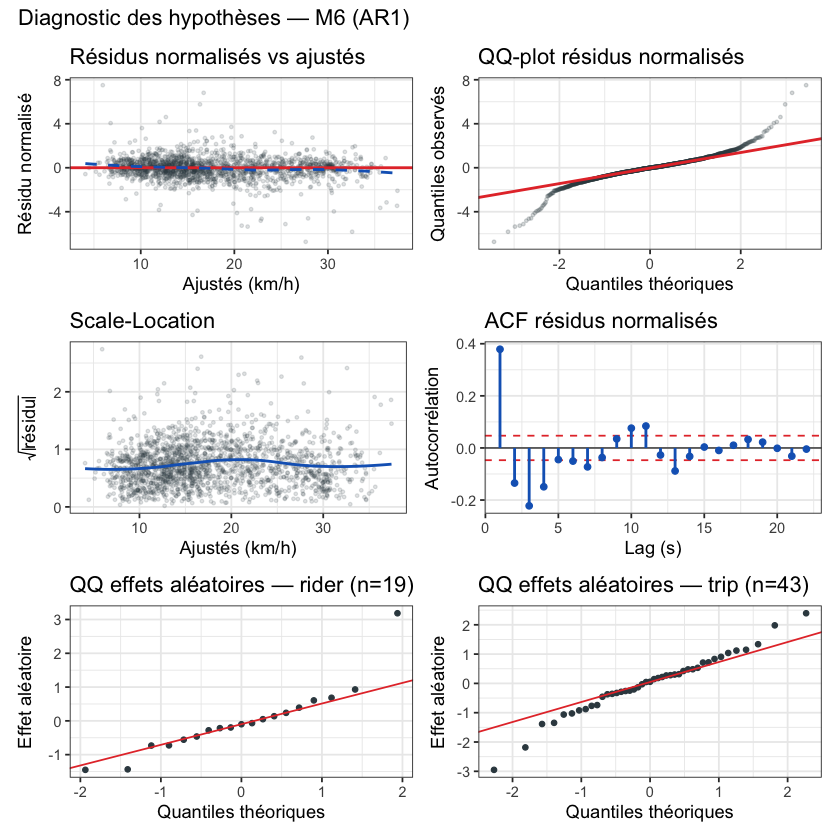

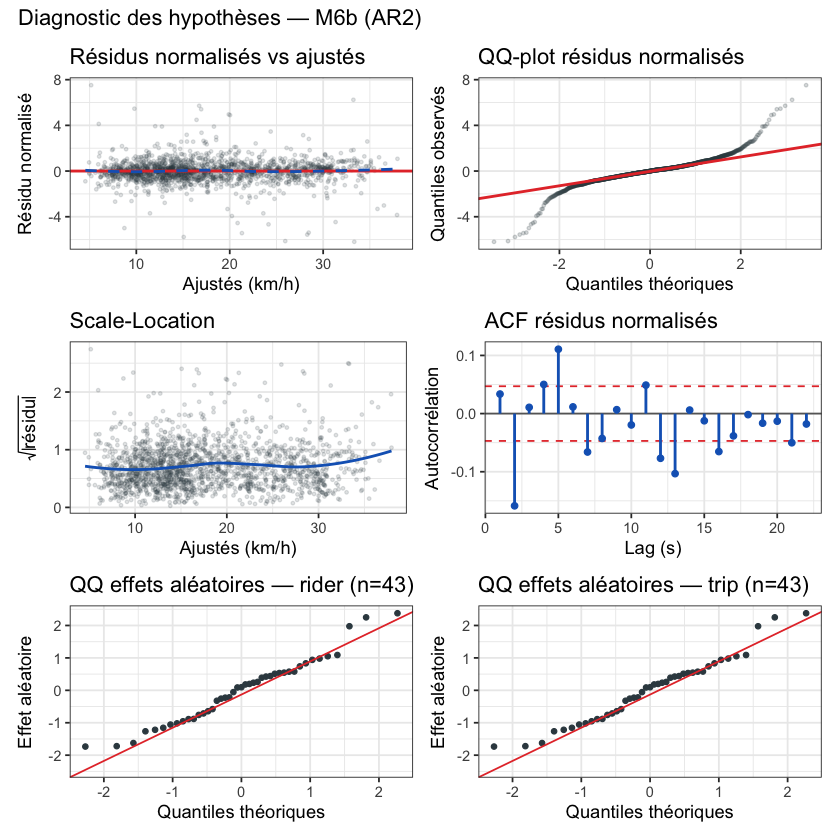

In [13]:
# ── Fonction de diagnostic des hypothèses pour un modèle nlme::lme ────────────
diag_lme_assumptions <- function(fit, model_name) {
  library(ggplot2); library(patchwork)
  d   <- nlme::getData(fit)
  rr  <- as.numeric(resid(fit, type = "normalized"))   # résidus décorrélés (AR pris en compte)
  fitv<- as.numeric(fitted(fit))
  zc  <- function(x) (x - mean(x)) / sd(x)
  n   <- length(rr)
  pdf <- data.frame(fitted = fitv, resid = rr)

  # 1. Résidus vs ajustés
  p1 <- ggplot(pdf, aes(fitted, resid)) +
    geom_point(alpha = 0.15, size = 0.7, color = "#37474F") +
    geom_hline(yintercept = 0, color = "#E53935", linewidth = 0.8) +
    geom_smooth(method = "loess", se = FALSE, color = "#1565C0", linewidth = 0.8, linetype = "dashed") +
    labs(title = "Résidus normalisés vs ajustés", x = "Ajustés (km/h)", y = "Résidu normalisé") +
    theme_bw(base_size = 11)

  # 2. QQ-plot résidus
  p2 <- ggplot(pdf, aes(sample = resid)) +
    stat_qq(alpha = 0.2, size = 0.7, color = "#37474F") + stat_qq_line(color = "#E53935", linewidth = 0.8) +
    labs(title = "QQ-plot résidus normalisés", x = "Quantiles théoriques", y = "Quantiles observés") +
    theme_bw(base_size = 11)

  # 3. Scale-location (homoscédasticité)
  p3 <- ggplot(pdf, aes(fitted, sqrt(abs(resid)))) +
    geom_point(alpha = 0.15, size = 0.7, color = "#37474F") +
    geom_smooth(method = "loess", se = FALSE, color = "#1565C0", linewidth = 0.8) +
    labs(title = "Scale-Location", x = "Ajustés (km/h)", y = expression(sqrt(abs("résidu")))) +
    theme_bw(base_size = 11)

  # 4. ACF 
  ac  <- nlme::ACF(fit, resType = "normalized")
  ci  <- 1.96 / sqrt(n)
  p4 <- ggplot(ac[ac$lag > 0, ], aes(lag, ACF)) +
    geom_hline(yintercept = c(-ci, ci), linetype = "dashed", color = "#E53935") +
    geom_hline(yintercept = 0, color = "grey40") +
    geom_segment(aes(xend = lag, yend = 0), color = "#1565C0", linewidth = 0.8) +
    geom_point(color = "#1565C0", size = 1.5) +
    labs(title = "ACF résidus normalisés", x = "Lag (s)", y = "Autocorrélation") +
    theme_bw(base_size = 11)

  # 5-6. QQ-plots of rando effects
  re1 <- ranef(fit, level = 1)[, 1]
  p5 <- ggplot(data.frame(re = zc(re1)), aes(sample = re)) +
    stat_qq(size = 1.2, color = "#37474F") + stat_qq_line(color = "#E53935") +
    labs(title = sprintf("QQ effets aléatoires — rider (n=%d)", length(re1)),
         x = "Quantiles théoriques", y = "Effet aléatoire") + theme_bw(base_size = 11)
  re2 <- tryCatch(ranef(fit, level = 2)[, 1], error = function(e) NULL)
  p6 <- if (!is.null(re2) && length(re2) > 2) {
    ggplot(data.frame(re = zc(re2)), aes(sample = re)) +
      stat_qq(size = 1.2, color = "#37474F") + stat_qq_line(color = "#E53935") +
      labs(title = sprintf("QQ effets aléatoires — trip (n=%d)", length(re2)),
           x = "Quantiles théoriques", y = "Effet aléatoire") + theme_bw(base_size = 11)
  } else plot_spacer()

  fig <- (p1 | p2) / (p3 | p4) / (p5 | p6) +
    plot_annotation(title = sprintf("Diagnostic des hypothèses — %s", model_name))
  print(fig)


}

diag_lme_assumptions(r6$fit,  "M6 (AR1)")
diag_lme_assumptions(r6b$fit, "M6b (AR2)")

##  Likelihood ratio test between models


In [14]:

suppressPackageStartupMessages({ library(nlme); library(dplyr) })

.f_grid <- as.formula(paste("speed_kmh_kalman_t1 ~", rhs_m6))
.vg     <- unique(c("speed_kmh_kalman_t1", "rider_id", "source", "second",
                    all.vars(as.formula(paste("~", rhs_m6)))))
.vg     <- .vg[.vg %in% names(df_model)]
dat_g   <- df_model[, .vg, drop = FALSE]
for (cn in names(dat_g)) if (is.character(dat_g[[cn]])) dat_g[[cn]] <- factor(dat_g[[cn]])
dat_g   <- dat_g[complete.cases(dat_g), ]
dat_g   <- dat_g[order(dat_g$rider_id, dat_g$source, dat_g$second), ]

.ctrl_lme <- nlme::lmeControl(opt = "nlminb", maxIter = 300, msMaxIter = 300, returnObject = TRUE)
.ctrl_gls <- nlme::glsControl(maxIter = 300, msMaxIter = 300, returnObject = TRUE)
.ar_start <- function(p) switch(as.character(p), "1" = 0.8, "2" = c(0.5, 0.2), rep(0.2, p))

fit_lme_grp <- function(p, grp)
  nlme::lme(.f_grid, data = dat_g, method = "ML", control = .ctrl_lme,
            random = as.formula(paste("~ 1 |", grp)),
            correlation = if (p == 0) NULL
                          else nlme::corARMA(.ar_start(p),
                                             form = as.formula(paste("~ second |", grp)),
                                             p = p, q = 0))

m1 <- nlme::gls(.f_grid, data = dat_g, method = "ML", control = .ctrl_gls)  # no heterogeneity
m2 <- fit_lme_grp(0, "rider_id")                                            # rider only
m3 <- fit_lme_grp(0, "source")                                             # trip only

grp_full   <- "rider_id/source"                                            # M5 / M6a / M6b branch
full_chain <- tryCatch(lapply(0:2, fit_lme_grp, grp = grp_full),
  error = function(e) { message("  nested RE failed -> fallback ~ 1 | source (",
                                conditionMessage(e), ")")
                        grp_full <<- "source"; lapply(0:2, fit_lme_grp, grp = grp_full) })
m4 <- full_chain[[1]]   # M5   (rider + trip)
m5 <- full_chain[[2]]   # M6a  (M5 + AR1)
m6 <- full_chain[[3]]   # M6b  (M6a + AR2)



## Nested LR tests -----------------------------------------------------------
ll <- function(f) as.numeric(logLik(f))
kk <- function(f) attr(logLik(f), "df")
step <- function(big, small, lab) {
  lr  <- max(0, 2 * (ll(big) - ll(small))); df <- kk(big) - kk(small)
  crit <- qchisq(0.99, df)
  data.frame(Models = lab, LR = lr, df = df, crit = crit,
             H0 = ifelse(lr > crit, "Rejected", "Not rejected"),
             stringsAsFactors = FALSE)
}
tab <- rbind(
  step(m2, m1, "Model 2 vs Model 1"),   # rider random effect
  step(m3, m1, "Model 3 vs Model 1"),   # trip random effect
  step(m4, m2, "Model 4 vs Model 2"),   # + trip (given rider)
  step(m4, m3, "Model 4 vs Model 3"),   # + rider (given trip)
  step(m5, m4, "Model 5 vs Model 4"),   # AR(1)
  step(m6, m5, "Model 6 vs Model 5"))   # AR(2)


cat(sprintf("N = %s obs | %d trips | %d riders\n",
            format(nrow(dat_g), big.mark = " "),
            dplyr::n_distinct(dat_g$source), dplyr::n_distinct(dat_g$rider_id)))
cat("Model 1 = M5 no heterogeneity (GLS) | Model 2 = rider only | Model 3 = trip only\n")
cat("Model 4 = M5 (rider+trip) | Model 5 = M6a (AR1) | Model 6 = M6b (AR2)\n")
print(transform(tab, LR = round(LR, 2), crit = round(crit, 2)), row.names = FALSE)





N = 1 738 obs | 43 trips | 19 riders
Model 1 = M5 no heterogeneity (GLS) | Model 2 = rider only | Model 3 = trip only
Model 4 = M5 (rider+trip) | Model 5 = M6a (AR1) | Model 6 = M6b (AR2)
             Models      LR df crit           H0
 Model 2 vs Model 1    4.04  1 6.63 Not rejected
 Model 3 vs Model 1    5.81  1 6.63 Not rejected
 Model 4 vs Model 2    1.95  1 6.63 Not rejected
 Model 4 vs Model 3    0.17  1 6.63 Not rejected
 Model 5 vs Model 4 1509.32  1 6.63     Rejected
 Model 6 vs Model 5  575.23  1 6.63     Rejected
